# 7-0. 전국 net_load → 가스 발전 EDA (G-9 게이트 산출물)

> PROJECT.md §5.0.5 / Decision Gate **G-9**.
> 목적: 모델링(7-A) 착수 전에 **명제가 데이터에 실제로 있는지** 확인한다.
> "데이터가 멀쩡한가"(G-6, 구조)는 끝났고, 여기서는 **관계**를 본다.

확인 항목:
1. 타깃(`gen_gas_kr`) 분포 — 0(가스 꺼짐) 비중
2. `net_load_kr` ↔ `gen_gas_kr` 관계의 강도·형태(부하수준별 비선형)
3. 시계열 구조(시·요일·월 주기성, 연도 추세)
4. **시간적 안정성** — 연도별로 같은 net_load의 가스 발전이 표류하는가
5. **train(2020–23) ↔ test(2025~) net_load 분포 겹침** — 외삽 위험


In [1]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from pathlib import Path

mpl.rcParams['figure.dpi'] = 110
mpl.rcParams['axes.grid'] = True
mpl.rcParams['font.size'] = 10

DATA = Path('../../1. data_fetcher_and_db/second_dataset/data/land_full.parquet')
FIG = Path('fig'); FIG.mkdir(exist_ok=True)
TAB = Path('tab'); TAB.mkdir(exist_ok=True)

df = pd.read_parquet(DATA)
df = df[df['model_usable']].copy()          # 실측 타깃만(전국은 사실상 전 구간)
df['timestamp'] = pd.to_datetime(df['timestamp'])
print('실측 사용 행수', len(df), '| 기간', df['timestamp'].min(), '->', df['timestamp'].max())
df[['net_load_kr','gen_gas_kr']].describe().round(1)


실측 사용 행수 56342 | 기간 2020-01-01 00:00:00 -> 2026-06-05 13:00:00


,net_load_kr,gen_gas_kr
count,56342.0,56342.0
mean,63294.5,12999.4
std,9761.2,9935.2
min,32020.7,0.0
25%,56204.8,0.0
50%,62314.4,14798.2
75%,69366.8,20533.5
max,99659.9,39419.4


## 1. 타깃 분포 — 가스가 꺼지는 시간(0)이 얼마나 되나

gen_gas_kr == 0 비율: 30.7%
gen_gas_kr > 0 일 때 평균: 18762 MW


C:\Users\bjkim\AppData\Local\Temp\ipykernel_3496\836030130.py:10: UserWarning: Glyph 51204 (\N{HANGUL SYLLABLE JEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.savefig(FIG/'01_target_dist.png'); plt.show()
C:\Users\bjkim\AppData\Local\Temp\ipykernel_3496\836030130.py:10: UserWarning: Glyph 52404 (\N{HANGUL SYLLABLE CE}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.savefig(FIG/'01_target_dist.png'); plt.show()
C:\Users\bjkim\AppData\Local\Temp\ipykernel_3496\836030130.py:10: UserWarning: Glyph 48516 (\N{HANGUL SYLLABLE BUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.savefig(FIG/'01_target_dist.png'); plt.show()
C:\Users\bjkim\AppData\Local\Temp\ipykernel_3496\836030130.py:10: UserWarning: Glyph 54252 (\N{HANGUL SYLLABLE PO}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.savefig(FIG/'01_target_dist.png'); plt.show()
C:\Users\bjkim\AppData\Local\Temp\ipykernel_3496\836030130.py:10: UserWarning: Glyph 47564 (\N{HANGUL SYLLABL

C:\Users\bjkim\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 51204 (\N{HANGUL SYLLABLE JEON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\bjkim\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 52404 (\N{HANGUL SYLLABLE CE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\bjkim\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 48516 (\N{HANGUL SYLLABLE BUN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\bjkim\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 54252 (\N{HANGUL SYLLABLE PO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\bjkim\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 47564 (\N{HANGUL SYLLABLE MAN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_i

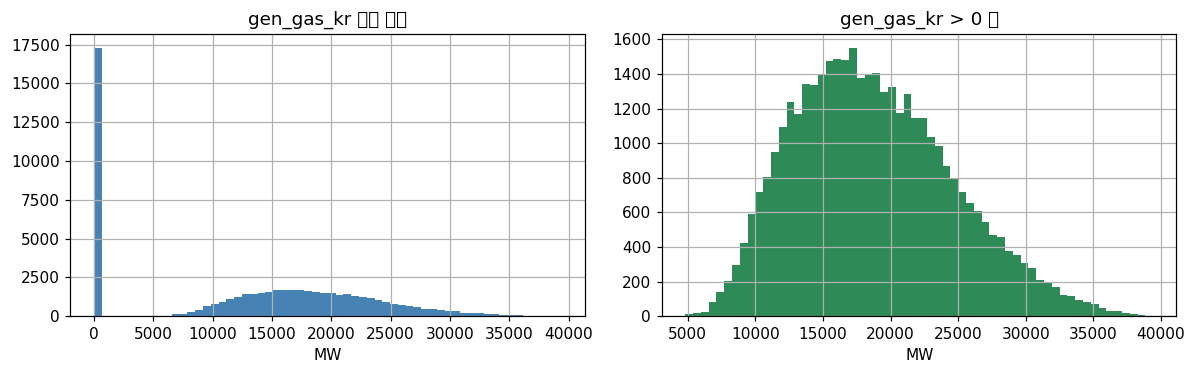

In [2]:
zero_rate = (df['gen_gas_kr'] == 0).mean()
print(f'gen_gas_kr == 0 비율: {zero_rate:.1%}')
print(f'gen_gas_kr > 0 일 때 평균: {df.loc[df.gen_gas_kr>0,"gen_gas_kr"].mean():.0f} MW')

fig, ax = plt.subplots(1, 2, figsize=(11, 3.5))
ax[0].hist(df['gen_gas_kr'], bins=60, color='steelblue')
ax[0].set_title('gen_gas_kr 전체 분포'); ax[0].set_xlabel('MW')
ax[1].hist(df.loc[df.gen_gas_kr>0,'gen_gas_kr'], bins=60, color='seagreen')
ax[1].set_title('gen_gas_kr > 0 만'); ax[1].set_xlabel('MW')
plt.tight_layout(); plt.savefig(FIG/'01_target_dist.png'); plt.show()


**읽는 법**: 0 비중이 크면 타깃이 영(0) 과다(zero-inflated)다.
저부하에선 가스가 급전순위상 아예 안 켜지는 merit-order 거동 → 모델은 이 임계 거동을 잡아야 한다.

## 2. net_load_kr ↔ gen_gas_kr 관계 (핵심 — 명제 그 자체)

C:\Users\bjkim\AppData\Local\Temp\ipykernel_3496\3201235229.py:23: UserWarning: Glyph 44288 (\N{HANGUL SYLLABLE GWAN}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.savefig(FIG/'02_netload_vs_gas.png'); plt.show()
C:\Users\bjkim\AppData\Local\Temp\ipykernel_3496\3201235229.py:23: UserWarning: Glyph 44228 (\N{HANGUL SYLLABLE GYE}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.savefig(FIG/'02_netload_vs_gas.png'); plt.show()
C:\Users\bjkim\AppData\Local\Temp\ipykernel_3496\3201235229.py:23: UserWarning: Glyph 51204 (\N{HANGUL SYLLABLE JEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.savefig(FIG/'02_netload_vs_gas.png'); plt.show()
C:\Users\bjkim\AppData\Local\Temp\ipykernel_3496\3201235229.py:23: UserWarning: Glyph 52404 (\N{HANGUL SYLLABLE CE}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.savefig(FIG/'02_netload_vs_gas.png'); plt.show()
C:\Users\bjkim\AppData\Local\Temp\ipykernel_3496\3201235229.py:23: UserWarning: Glyph 44396

전체 피어슨 상관 r = 0.470


C:\Users\bjkim\AppData\Local\Temp\ipykernel_3496\3201235229.py:23: UserWarning: Glyph 44032 (\N{HANGUL SYLLABLE GA}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.savefig(FIG/'02_netload_vs_gas.png'); plt.show()
C:\Users\bjkim\AppData\Local\Temp\ipykernel_3496\3201235229.py:23: UserWarning: Glyph 49828 (\N{HANGUL SYLLABLE SEU}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.savefig(FIG/'02_netload_vs_gas.png'); plt.show()
C:\Users\bjkim\AppData\Local\Temp\ipykernel_3496\3201235229.py:23: UserWarning: Glyph 48708 (\N{HANGUL SYLLABLE BI}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.savefig(FIG/'02_netload_vs_gas.png'); plt.show()
C:\Users\bjkim\AppData\Local\Temp\ipykernel_3496\3201235229.py:23: UserWarning: Glyph 50984 (\N{HANGUL SYLLABLE YUL}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.savefig(FIG/'02_netload_vs_gas.png'); plt.show()
C:\Users\bjkim\AppData\Local\Temp\ipykernel_3496\3201235229.py:23: UserWarning: Glyph 48512 (\

C:\Users\bjkim\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 44288 (\N{HANGUL SYLLABLE GWAN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\bjkim\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 44228 (\N{HANGUL SYLLABLE GYE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\bjkim\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 51204 (\N{HANGUL SYLLABLE JEON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\bjkim\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 52404 (\N{HANGUL SYLLABLE CE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\bjkim\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 44396 (\N{HANGUL SYLLABLE GU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_

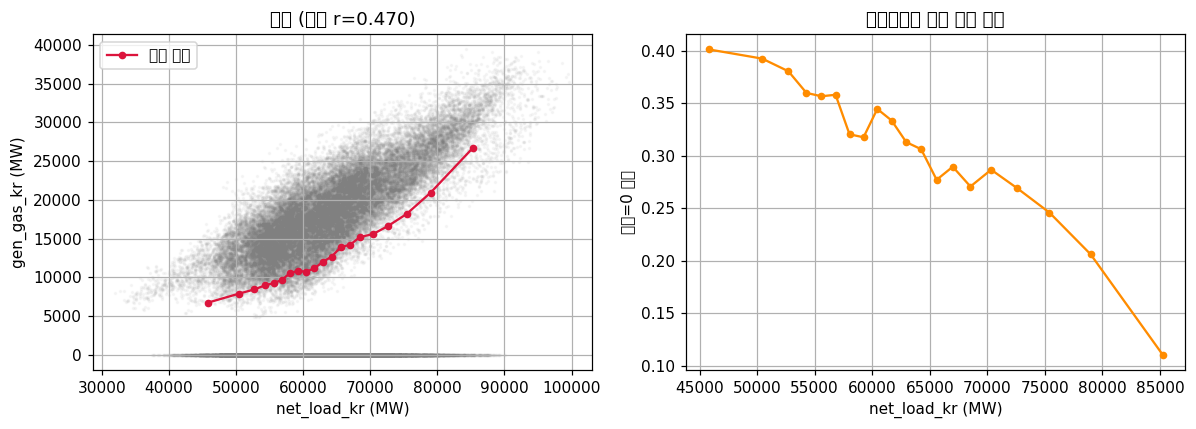

,net_load,gas_mean,gas_std,zero_rate,n
0,45802.9,6724.7,5814.2,0.4,2818
1,50434.2,7888.2,6726.7,0.4,2817
2,52714.7,8430.5,6983.3,0.4,2817
3,54281.7,8948.4,7118.7,0.4,2817
4,55585.0,9249.9,7332.0,0.4,2817
5,56813.1,9654.3,7697.5,0.4,2817
6,58023.4,10525.3,7797.7,0.3,2817
7,59243.7,10855.7,7980.3,0.3,2817
8,60436.4,10682.3,8318.0,0.3,2817
9,61683.5,11175.9,8442.7,0.3,2817


In [3]:
from numpy import corrcoef
r_all = corrcoef(df['net_load_kr'], df['gen_gas_kr'])[0,1]
print(f'전체 피어슨 상관 r = {r_all:.3f}')

# 부하수준 20분위 구간별 평균 가스 발전
df['nl_bin'] = pd.qcut(df['net_load_kr'], 20, duplicates='drop')
g = df.groupby('nl_bin', observed=True).agg(
    net_load=('net_load_kr','mean'),
    gas_mean=('gen_gas_kr','mean'),
    gas_std=('gen_gas_kr','std'),
    zero_rate=('gen_gas_kr', lambda s:(s==0).mean()),
    n=('gen_gas_kr','size')).reset_index(drop=True)
g.round(1).to_csv(TAB/'02_netload_vs_gas_binned.csv', index=False)

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].scatter(df['net_load_kr'], df['gen_gas_kr'], s=2, alpha=0.05, color='gray')
ax[0].plot(g['net_load'], g['gas_mean'], '-o', color='crimson', ms=4, label='구간 평균')
ax[0].set_xlabel('net_load_kr (MW)'); ax[0].set_ylabel('gen_gas_kr (MW)')
ax[0].set_title(f'관계 (전체 r={r_all:.3f})'); ax[0].legend()
ax[1].plot(g['net_load'], g['zero_rate'], '-o', color='darkorange', ms=4)
ax[1].set_xlabel('net_load_kr (MW)'); ax[1].set_ylabel('가스=0 비율')
ax[1].set_title('부하수준별 가스 꺼짐 비율')
plt.tight_layout(); plt.savefig(FIG/'02_netload_vs_gas.png'); plt.show()
g.round(1)


**읽는 법**: 구간 평균선이 우상향하면 net_load↑ → 가스↑ (명제 성립의 직접 증거).
직선이 아니라 저부하 평탄 → 고부하 급증이면 **부하수준별 비선형**(merit-order). 모델은 선형보다 트리/구간 모델이 유리할 신호.

## 3. 시계열 구조 — 주기성과 연도 추세

C:\Users\bjkim\AppData\Local\Temp\ipykernel_3496\1207530449.py:10: UserWarning: Glyph 49884 (\N{HANGUL SYLLABLE SI}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.savefig(FIG/'03_seasonality.png'); plt.show()
C:\Users\bjkim\AppData\Local\Temp\ipykernel_3496\1207530449.py:10: UserWarning: Glyph 44036 (\N{HANGUL SYLLABLE GAN}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.savefig(FIG/'03_seasonality.png'); plt.show()
C:\Users\bjkim\AppData\Local\Temp\ipykernel_3496\1207530449.py:10: UserWarning: Glyph 45824 (\N{HANGUL SYLLABLE DAE}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.savefig(FIG/'03_seasonality.png'); plt.show()
C:\Users\bjkim\AppData\Local\Temp\ipykernel_3496\1207530449.py:10: UserWarning: Glyph 48324 (\N{HANGUL SYLLABLE BYEOL}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.savefig(FIG/'03_seasonality.png'); plt.show()
C:\Users\bjkim\AppData\Local\Temp\ipykernel_3496\1207530449.py:10: UserWarning: Glyph 54217 (\N{HANGUL 

C:\Users\bjkim\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 49884 (\N{HANGUL SYLLABLE SI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\bjkim\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 44036 (\N{HANGUL SYLLABLE GAN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\bjkim\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 45824 (\N{HANGUL SYLLABLE DAE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\bjkim\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 48324 (\N{HANGUL SYLLABLE BYEOL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\bjkim\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 54217 (\N{HANGUL SYLLABLE PYEONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(by

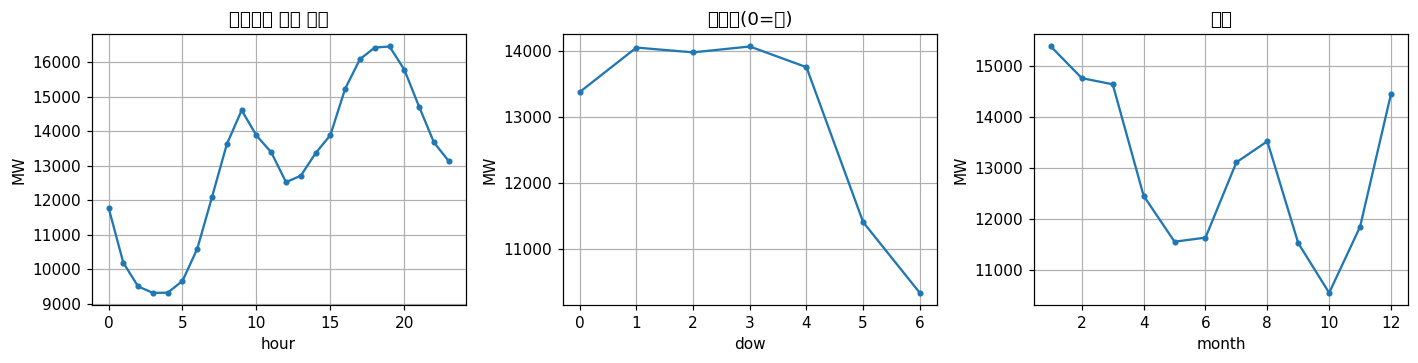

C:\Users\bjkim\AppData\Local\Temp\ipykernel_3496\1207530449.py:16: UserWarning: Glyph 50900 (\N{HANGUL SYLLABLE WEOL}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.savefig(FIG/'03_monthly_trend.png'); plt.show()
C:\Users\bjkim\AppData\Local\Temp\ipykernel_3496\1207530449.py:16: UserWarning: Glyph 54217 (\N{HANGUL SYLLABLE PYEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.savefig(FIG/'03_monthly_trend.png'); plt.show()
C:\Users\bjkim\AppData\Local\Temp\ipykernel_3496\1207530449.py:16: UserWarning: Glyph 44512 (\N{HANGUL SYLLABLE GYUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.savefig(FIG/'03_monthly_trend.png'); plt.show()
C:\Users\bjkim\AppData\Local\Temp\ipykernel_3496\1207530449.py:16: UserWarning: Glyph 52628 (\N{HANGUL SYLLABLE CU}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.savefig(FIG/'03_monthly_trend.png'); plt.show()
C:\Users\bjkim\AppData\Local\Temp\ipykernel_3496\1207530449.py:16: UserWarning: Glyph 51060 

C:\Users\bjkim\AppData\Local\Temp\ipykernel_3496\1207530449.py:16: UserWarning: Glyph 50900 (\N{HANGUL SYLLABLE WEOL}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.savefig(FIG/'03_monthly_trend.png'); plt.show()
C:\Users\bjkim\AppData\Local\Temp\ipykernel_3496\1207530449.py:16: UserWarning: Glyph 54217 (\N{HANGUL SYLLABLE PYEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.savefig(FIG/'03_monthly_trend.png'); plt.show()
C:\Users\bjkim\AppData\Local\Temp\ipykernel_3496\1207530449.py:16: UserWarning: Glyph 44512 (\N{HANGUL SYLLABLE GYUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.savefig(FIG/'03_monthly_trend.png'); plt.show()
C:\Users\bjkim\AppData\Local\Temp\ipykernel_3496\1207530449.py:16: UserWarning: Glyph 52628 (\N{HANGUL SYLLABLE CU}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.savefig(FIG/'03_monthly_trend.png'); plt.show()
C:\Users\bjkim\AppData\Local\Temp\ipykernel_3496\1207530449.py:16: UserWarning: Glyph 51060 

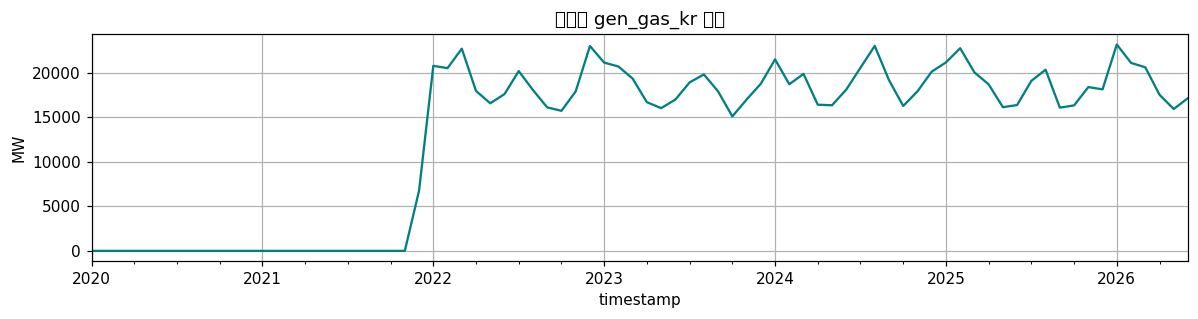

In [4]:
prof_hour = df.groupby('hour')['gen_gas_kr'].mean()
prof_dow  = df.groupby('dow')['gen_gas_kr'].mean()
prof_month= df.groupby('month')['gen_gas_kr'].mean()

fig, ax = plt.subplots(1, 3, figsize=(13, 3.4))
prof_hour.plot(ax=ax[0], marker='o', ms=3); ax[0].set_title('시간대별 평균 가스'); ax[0].set_xlabel('hour')
prof_dow.plot(ax=ax[1], marker='o', ms=3); ax[1].set_title('요일별(0=월)'); ax[1].set_xlabel('dow')
prof_month.plot(ax=ax[2], marker='o', ms=3); ax[2].set_title('월별'); ax[2].set_xlabel('month')
for a in ax: a.set_ylabel('MW')
plt.tight_layout(); plt.savefig(FIG/'03_seasonality.png'); plt.show()

# 연도 추세 (월평균 시계열)
ms = df.set_index('timestamp')['gen_gas_kr'].resample('MS').mean()
fig, ax = plt.subplots(figsize=(11, 3))
ms.plot(ax=ax, color='teal'); ax.set_title('월평균 gen_gas_kr 추이'); ax.set_ylabel('MW')
plt.tight_layout(); plt.savefig(FIG/'03_monthly_trend.png'); plt.show()


**읽는 법**: 시·요일·월 패턴 → 달력 피처가 유효. 월평균 추이에 계단/추세가 있으면 레짐 변화 신호(아래 4와 연결).

## 4. 시간적 안정성 — 같은 net_load의 가스 발전이 연도별로 표류하나 (★)

C:\Users\bjkim\AppData\Local\Temp\ipykernel_3496\948283061.py:13: UserWarning: Glyph 44256 (\N{HANGUL SYLLABLE GO}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.savefig(FIG/'04_yearly_stability.png'); plt.show()
C:\Users\bjkim\AppData\Local\Temp\ipykernel_3496\948283061.py:13: UserWarning: Glyph 51221 (\N{HANGUL SYLLABLE JEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.savefig(FIG/'04_yearly_stability.png'); plt.show()


C:\Users\bjkim\AppData\Local\Temp\ipykernel_3496\948283061.py:13: UserWarning: Glyph 44396 (\N{HANGUL SYLLABLE GU}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.savefig(FIG/'04_yearly_stability.png'); plt.show()
C:\Users\bjkim\AppData\Local\Temp\ipykernel_3496\948283061.py:13: UserWarning: Glyph 44036 (\N{HANGUL SYLLABLE GAN}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.savefig(FIG/'04_yearly_stability.png'); plt.show()
C:\Users\bjkim\AppData\Local\Temp\ipykernel_3496\948283061.py:13: UserWarning: Glyph 54217 (\N{HANGUL SYLLABLE PYEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.savefig(FIG/'04_yearly_stability.png'); plt.show()
C:\Users\bjkim\AppData\Local\Temp\ipykernel_3496\948283061.py:13: UserWarning: Glyph 44512 (\N{HANGUL SYLLABLE GYUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.savefig(FIG/'04_yearly_stability.png'); plt.show()
C:\Users\bjkim\AppData\Local\Temp\ipykernel_3496\948283061.py:13: UserWarning: Glyph 

C:\Users\bjkim\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 54217 (\N{HANGUL SYLLABLE PYEONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\bjkim\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 44512 (\N{HANGUL SYLLABLE GYUN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


C:\Users\bjkim\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 50672 (\N{HANGUL SYLLABLE YEON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\bjkim\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 46020 (\N{HANGUL SYLLABLE DO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\bjkim\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 48324 (\N{HANGUL SYLLABLE BYEOL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\bjkim\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 44032 (\N{HANGUL SYLLABLE GA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\bjkim\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 49828 (\N{HANGUL SYLLABLE SEU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes

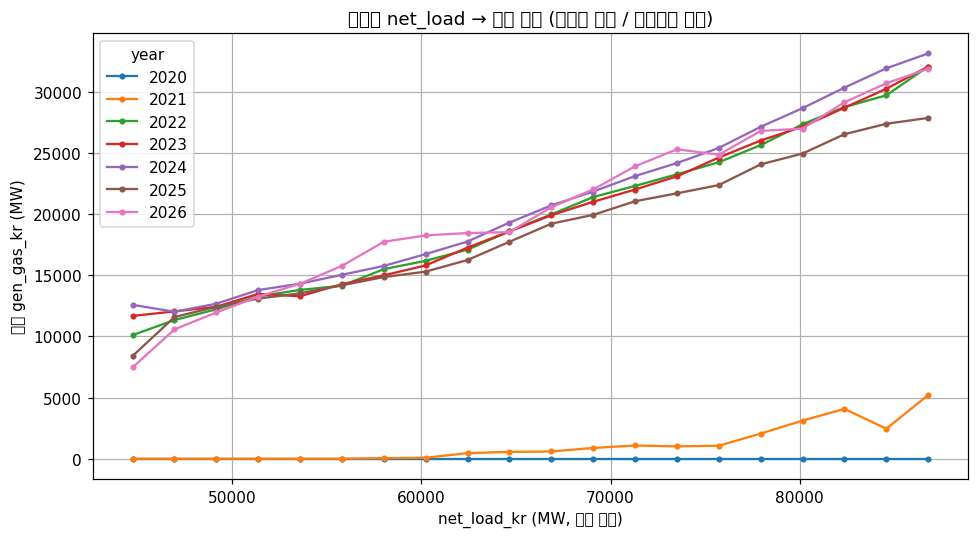

year,2020,2021,2022,2023,2024,2025,2026
nl_fix,,,,,,,
"(43615.514, 45829.816]",0.0,0.0,10100.0,11671.0,12576.0,8391.0,7458.0
"(45829.816, 48044.118]",0.0,0.0,11333.0,12035.0,12008.0,11575.0,10564.0
"(48044.118, 50258.42]",0.0,0.0,12210.0,12417.0,12669.0,12415.0,11953.0
"(50258.42, 52472.722]",0.0,0.0,13263.0,13466.0,13782.0,13084.0,13240.0
"(52472.722, 54687.025]",0.0,0.0,13792.0,13277.0,14302.0,13514.0,14299.0
"(54687.025, 56901.327]",0.0,0.0,14135.0,14266.0,15030.0,14174.0,15756.0
"(56901.327, 59115.629]",0.0,48.0,15490.0,14981.0,15754.0,14841.0,17726.0
"(59115.629, 61329.931]",0.0,81.0,16172.0,15797.0,16723.0,15291.0,18245.0
"(61329.931, 63544.233]",0.0,458.0,17088.0,17251.0,17750.0,16239.0,18442.0


In [5]:
# 연도별 부하수준-가스 곡선 겹쳐보기 (공통 구간으로 binning)
bins = np.linspace(df['net_load_kr'].quantile(.01), df['net_load_kr'].quantile(.99), 21)
df['nl_fix'] = pd.cut(df['net_load_kr'], bins)
piv = df.groupby(['year','nl_fix'], observed=True)['gen_gas_kr'].mean().unstack('year')
centers = [iv.mid for iv in piv.index]

fig, ax = plt.subplots(figsize=(9, 5))
for y in piv.columns:
    ax.plot(centers, piv[y].values, marker='o', ms=3, label=str(y))
ax.set_xlabel('net_load_kr (MW, 고정 구간)'); ax.set_ylabel('평균 gen_gas_kr (MW)')
ax.set_title('연도별 net_load → 가스 곡선 (겹치면 안정 / 벌어지면 표류)')
ax.legend(title='year')
plt.tight_layout(); plt.savefig(FIG/'04_yearly_stability.png'); plt.show()
piv.round(0)


**읽는 법**: 연도 곡선이 거의 겹치면 함수 f(net_load)→gas가 **안정**(좋음).
한 방향으로 벌어지면 석탄·원전·신재생 증감으로 가스의 급전순위 위치가 **표류** → year/레짐 피처 필요 + test 성능 기대치 하향. G-9의 핵심 판단.

### 4-b. ★ 발견: 2020–2021은 실측 아님(결측을 0으로 채움) — G-10
연도별 0 비율을 보면 **2020년 100%, 2021년 97%가 0**(2020 max=0). `gen_gas_kr` 실측은 **2022-01부터** 시작된다(2021-12은 전환기).
즉 위 4번에서 2020·2021 곡선이 바닥인 건 표류가 아니라 **데이터가 없는 것**이다.
A0 구조 감사(G-6)는 NaN만 봤는데 이 값들은 NaN이 아니라 0이라 통과했고, `model_usable`도 잘못 True로 라벨됐다.
**현재 공식 분할 train=2020–2023은 절반이 가짜다.** → 학습창을 2022+로 재정의해야 한다(게이트 G-10).

In [6]:
yr = df.groupby('year')['gen_gas_kr'].agg(
        mean='mean', max='max',
        zero_pct=lambda s:(s==0).mean()*100).round(0)
yr.to_csv(TAB/'04b_yearly_availability.csv')
clean = df[df['timestamp'] >= '2022-01-01'].dropna(subset=['net_load_kr','gen_gas_kr'])
r_clean = np.corrcoef(clean['net_load_kr'], clean['gen_gas_kr'])[0,1]
print(f'[2020-2021 제외 후] 2022+ 유효행 {len(clean)} | gas 0비율 {(clean.gen_gas_kr==0).mean():.1%} | gas 최소 {clean.gen_gas_kr.min():.0f}MW')
print(f'[2022+] net_load↔gas 상관 r = {r_clean:.3f}  (2020-21 포함 시 0.47에서 회복)')
yr


[2020-2021 제외 후] 2022+ 유효행 38798 | gas 0비율 0.0% | gas 최소 4811MW
[2022+] net_load↔gas 상관 r = 0.830  (2020-21 포함 시 0.47에서 회복)


,mean,max,zero_pct
year,,,
2020,0.0,0.0,100.0
2021,573.0,35152.0,97.0
2022,18906.0,37383.0,0.0
2023,18166.0,37945.0,0.0
2024,18991.0,38558.0,0.0
2025,18585.0,39076.0,0.0
2026,19557.0,39419.0,0.0


## 5. train(2020–23) ↔ test(2025~) 입력 분포 겹침 — 외삽 위험 (★)

C:\Users\bjkim\AppData\Local\Temp\ipykernel_3496\2866523285.py:9: UserWarning: Glyph 48324 (\N{HANGUL SYLLABLE BYEOL}) missing from font(s) DejaVu Sans.
  ax.legend(); plt.tight_layout(); plt.savefig(FIG/'05_split_distribution.png'); plt.show()
C:\Users\bjkim\AppData\Local\Temp\ipykernel_3496\2866523285.py:9: UserWarning: Glyph 48516 (\N{HANGUL SYLLABLE BUN}) missing from font(s) DejaVu Sans.
  ax.legend(); plt.tight_layout(); plt.savefig(FIG/'05_split_distribution.png'); plt.show()
C:\Users\bjkim\AppData\Local\Temp\ipykernel_3496\2866523285.py:9: UserWarning: Glyph 54252 (\N{HANGUL SYLLABLE PO}) missing from font(s) DejaVu Sans.
  ax.legend(); plt.tight_layout(); plt.savefig(FIG/'05_split_distribution.png'); plt.show()


C:\Users\bjkim\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 48324 (\N{HANGUL SYLLABLE BYEOL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\bjkim\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 48516 (\N{HANGUL SYLLABLE BUN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\bjkim\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 54252 (\N{HANGUL SYLLABLE PO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


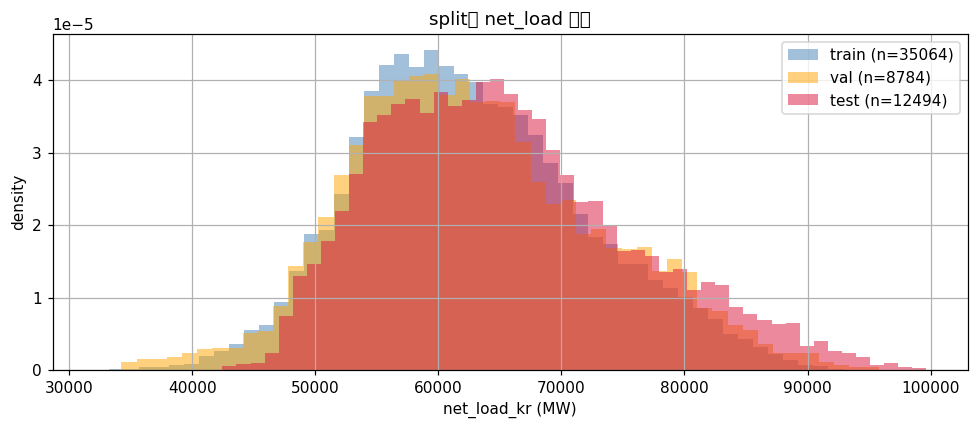

train net_load 범위: 32021 ~ 92866
train 범위를 벗어난 test 비율(외삽): 0.7%


,train,val,test
min,32021.0,34230.0,42442.0
q25,55929.0,55727.0,57526.0
median,61760.0,62012.0,64174.0
q75,68603.0,69622.0,71645.0
max,92866.0,95826.0,99660.0
mean,62627.0,63028.0,65356.0


In [7]:
full = pd.read_parquet(DATA)
full = full[full['split'].isin(['train','val','test'])].copy()
spl = {s: full.loc[full.split==s,'net_load_kr'].dropna() for s in ['train','val','test']}

fig, ax = plt.subplots(figsize=(9, 4))
for s,c in [('train','steelblue'),('val','orange'),('test','crimson')]:
    ax.hist(spl[s], bins=50, density=True, alpha=0.5, label=f'{s} (n={len(spl[s])})', color=c)
ax.set_xlabel('net_load_kr (MW)'); ax.set_ylabel('density'); ax.set_title('split별 net_load 분포')
ax.legend(); plt.tight_layout(); plt.savefig(FIG/'05_split_distribution.png'); plt.show()

tr_lo, tr_hi = spl['train'].min(), spl['train'].max()
te = spl['test']
out = ((te < tr_lo) | (te > tr_hi)).mean()
summ = pd.DataFrame({s:[v.min(),v.quantile(.25),v.median(),v.quantile(.75),v.max(),v.mean()]
                     for s,v in spl.items()},
                    index=['min','q25','median','q75','max','mean']).round(0)
summ.to_csv(TAB/'05_split_netload_summary.csv')
print('train net_load 범위:', round(tr_lo), '~', round(tr_hi))
print(f'train 범위를 벗어난 test 비율(외삽): {out:.1%}')
summ


**읽는 법**: test가 train 범위를 크게 벗어나면 모델이 외삽 → "정직한 검증"이 흔들린다.
겹침이 충분하면 안심. 벗어남이 크면 학습창·피처(year 추세) 보정 필요. G-9의 또 다른 핵심 판단.

## 5-b. ★ 신재생 → 가스 대체효과 (명제의 심장) — 전국에선 약하다
명제(§1.2): 신재생↑ → 가스↓. net_load는 (수요−신재생)이라 신재생의 음효과가 안 보인다.
**수요를 통제하고** `renew_gen_total_kr`(태양광+풍력 합계) ↔ 가스의 관계를 직접 본다.

In [8]:
d2 = df[df['timestamp']>='2022-01-01'].dropna(
        subset=['renew_gen_total_kr','real_demand_land','net_load_kr','gen_gas_kr']).copy()
print('신재생 평균 %.0fMW (수요의 %.1f%%), 최대 %.0fMW' % (
    d2.renew_gen_total_kr.mean(), 100*d2.renew_gen_total_kr.mean()/d2.real_demand_land.mean(),
    d2.renew_gen_total_kr.max()))
print('원상관 corr(신재생,가스)=%+.3f | corr(수요,가스)=%+.3f | corr(net_load,가스)=%+.3f' % (
    np.corrcoef(d2.renew_gen_total_kr,d2.gen_gas_kr)[0,1],
    np.corrcoef(d2.real_demand_land,d2.gen_gas_kr)[0,1],
    np.corrcoef(d2.net_load_kr,d2.gen_gas_kr)[0,1]))

# 수요 통제: 수요 10분위 안에서 부분상관
d2['dem_dec'] = pd.qcut(d2.real_demand_land,10,labels=False)
pc = d2.groupby('dem_dec', group_keys=False).apply(
        lambda g: np.corrcoef(g.renew_gen_total_kr,g.gen_gas_kr)[0,1], include_groups=False)
print('수요분위별 부분상관 corr(신재생,가스):', [round(v,2) for v in pc.values], '| 평균 %+.3f'%pc.mean())

# 회귀계수
import numpy.linalg as la
X=np.column_stack([np.ones(len(d2)),d2.real_demand_land,d2.renew_gen_total_kr])
beta=la.lstsq(X,d2.gen_gas_kr.values,rcond=None)[0]
print('회귀 gas ~ 수요+신재생: 수요계수 %+.3f, 신재생계수 %+.3f (수요고정 시 신재생 +1000MW => 가스 %+.0fMW)'
      % (beta[1],beta[2],beta[2]*1000))


신재생 평균 1612MW (수요의 2.5%), 최대 10157MW
원상관 corr(신재생,가스)=+0.007 | corr(수요,가스)=+0.856 | corr(net_load,가스)=+0.829
수요분위별 부분상관 corr(신재생,가스): [-0.27, 0.06, 0.08, 0.1, 0.12, 0.06, -0.02, -0.01, -0.03, -0.04] | 평균 +0.006
회귀 gas ~ 수요+신재생: 수요계수 +0.508, 신재생계수 +0.105 (수요고정 시 신재생 +1000MW => 가스 +105MW)


C:\Users\bjkim\AppData\Local\Temp\ipykernel_3496\3777093500.py:13: UserWarning: Glyph 49888 (\N{HANGUL SYLLABLE SIN}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.savefig(FIG/'05b_renew_displacement.png'); plt.show()
C:\Users\bjkim\AppData\Local\Temp\ipykernel_3496\3777093500.py:13: UserWarning: Glyph 51116 (\N{HANGUL SYLLABLE JAE}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.savefig(FIG/'05b_renew_displacement.png'); plt.show()
C:\Users\bjkim\AppData\Local\Temp\ipykernel_3496\3777093500.py:13: UserWarning: Glyph 49373 (\N{HANGUL SYLLABLE SAENG}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.savefig(FIG/'05b_renew_displacement.png'); plt.show()
C:\Users\bjkim\AppData\Local\Temp\ipykernel_3496\3777093500.py:13: UserWarning: Glyph 44032 (\N{HANGUL SYLLABLE GA}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.savefig(FIG/'05b_renew_displacement.png'); plt.show()
C:\Users\bjkim\AppData\Local\Temp\ipykernel_3496\3777093500.py:13: User

C:\Users\bjkim\AppData\Local\Temp\ipykernel_3496\3777093500.py:13: UserWarning: Glyph 51473 (\N{HANGUL SYLLABLE JUNG}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.savefig(FIG/'05b_renew_displacement.png'); plt.show()
C:\Users\bjkim\AppData\Local\Temp\ipykernel_3496\3777093500.py:13: UserWarning: Glyph 44256 (\N{HANGUL SYLLABLE GO}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.savefig(FIG/'05b_renew_displacement.png'); plt.show()


C:\Users\bjkim\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 44032 (\N{HANGUL SYLLABLE GA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\bjkim\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 49828 (\N{HANGUL SYLLABLE SEU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\bjkim\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 51200 (\N{HANGUL SYLLABLE JEO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\bjkim\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\bjkim\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 50836 (\N{HANGUL SYLLABLE YO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io,

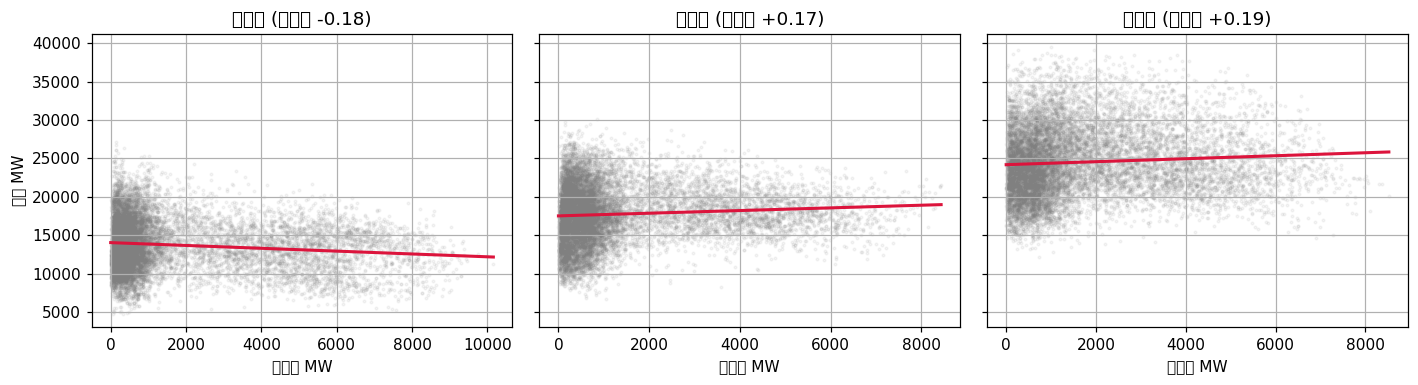

In [9]:
# 수요대(저/중/고)별 신재생 vs 가스 — 음의 기울기면 대체효과
fig, ax = plt.subplots(1,3, figsize=(13,3.6), sharey=True)
edges = d2.real_demand_land.quantile([0,.33,.66,1.0]).values
labels=['저수요','중수요','고수요']
for i,(lo,hi) in enumerate(zip(edges[:-1],edges[1:])):
    s=d2[(d2.real_demand_land>=lo)&(d2.real_demand_land<hi)]
    ax[i].scatter(s.renew_gen_total_kr,s.gen_gas_kr,s=3,alpha=0.08,color='gray')
    b=np.polyfit(s.renew_gen_total_kr,s.gen_gas_kr,1)
    xs=np.linspace(s.renew_gen_total_kr.min(),s.renew_gen_total_kr.max(),50)
    ax[i].plot(xs,np.polyval(b,xs),'crimson',lw=2)
    ax[i].set_title(f'{labels[i]} (기울기 {b[0]:+.2f})'); ax[i].set_xlabel('신재생 MW')
ax[0].set_ylabel('가스 MW')
plt.tight_layout(); plt.savefig(FIG/'05b_renew_displacement.png'); plt.show()


**읽는 법**: 수요대 안에서 기울기가 음(−)이면 신재생이 가스를 밀어내는 대체효과.
**결과**: 전국은 신재생이 수요의 ~2.5%로 작고(게다가 자가소비 태양광은 수요에 이미 차감되어 숨음),
회귀 신재생계수도 거의 0(약간 +). 즉 **전국에선 가스 ≈ f(수요)이고 대체효과는 희석된다.**
→ 대체효과 입증은 **침투율 높은 제주(7-B)** 의 몫. §1.2가 "신재생 많은 제주에서 입증"이라 한 설계가 맞다.

## 6. 요약 & 다음 단계 (실측 수치)

**관계는 강하고 안정적 — 명제(검증목표 2)는 데이터에 실제로 있다. 단, 데이터 결손 1건 발견.**

| 항목 | 결과 | 판정 |
|---|---|---|
| net_load↔gas 상관(2022+) | **r = 0.83** | 강함. net_load↑ → 가스↑ 직접 증거 |
| 관계 형태 | 우상향, 부하수준별 비선형(저부하 평탄→고부하 급증) | 트리/구간 모델 유리 |
| 타깃 0 비중(2022+) | **0%** (최소 4,811MW, 항상 켜짐) | 영 과다 아님 |
| 시계열 | 시·요일·월 주기성 뚜렷, 월평균 추세 완만 | 달력 피처 유효 |
| 시간적 안정성(2022+) | 60–65k 구간 가스 ~17,500MW로 연도 일정 | 안정. 표류 없음 |
| train↔test net_load 겹침 | 외삽 0.7%, 평균차 +2,729MW | 안전 |
| **신재생→가스 대체효과(5-b)** | 원상관 +0.01, 회귀 신재생계수 ≈ 0 | **전국은 약함**(침투율 낮음) → 제주 probe의 몫 |

**★ 단, 발견(4-b)**: `gen_gas_kr` 실측은 **2022-01부터**. 2020(100% 0)·2021(97% 0)은 결측을 0으로 채운 값이고 `model_usable`이 잘못 True다.
→ 현재 공식 분할 **train=2020–2023은 절반이 가짜** → 학습창 2022+로 재정의 필요.

**G-9 판정**: 관계·시계열·안정성·분포 겹침 모두 양호(통과 가능). 단 **데이터 결손(G-10)** 을 먼저 처리해야 모델 착수.
**열린 결정(G-10)**: 학습창/분할 재정의(예: train 2022–2023 / val 2024 / test 2025–2026).
**그 다음(§0.6 규율)**: G-10 확정 → 모델 **최종 입력 피처를 사용자에게 묻고 확정** → 7-A 착수.
